# Autoencoder for Anomaly Detection

### Notebook Structure
1. Setup & Imports
2. Load and preprocess data
3. Create `tf.data` pipelines for train / val / test
4. Build autoencoder architecture
5. Train on real news only (label = 0)
6. Calculate reconstruction errors on test data
7. Detect anomalies using statistical threshold
8. Evaluate performance
9. Visualise results
10. Save models and results

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.2.6


In [2]:
# Resolve project root so this notebook works from any working directory
cwd = Path.cwd()

def find_repo_root(start):
    for candidate in [start] + list(start.parents):
        if (candidate / "README.md").exists() or (candidate / "src").exists() or (candidate / ".git").exists():
            return candidate
    return start

BASE_DIR = find_repo_root(cwd)
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = BASE_DIR / "results" / "models"
FIGURES_DIR = BASE_DIR / "results" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(BASE_DIR / "src" / "features"))

print("BASE_DIR  :", BASE_DIR)
print("DATA_DIR  :", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

BASE_DIR  : c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers
DATA_DIR  : c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers\data
MODELS_DIR: c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers\results\models
FIGURES_DIR: c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers\results\figures


## 2. Load and Preprocess Data

In [3]:
from dl_text_preprocessing import (
    load_clean_data, split_data, build_tokenizer,
    text_to_sequence, apply_padding
)

# Configuration
MAX_WORDS    = 20000
MAX_LEN      = 20
EMBEDDING_DIM = 64
ENCODING_DIM  = 32   # bottleneck
BATCH_SIZE    = 128
MAX_EPOCHS    = 20
SHUFFLE_BUFFER_SIZE  = 10_000  # shuffle window for tf.data train pipeline
THRESHOLD_STD_MULTIPLIER = 2    # number of std-devs above mean for anomaly threshold

data_path = BASE_DIR / "data" / "processed" / "processed.csv"
print("Loading data from:", data_path)
df = load_clean_data(data_path)
print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df['target'].value_counts()}")

Loading data from: c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers\data\processed\processed.csv
Dataset shape: (1482190, 2)
Label distribution:
target
0    749664
1    732526
Name: count, dtype: int64


In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

print(f"X_train : {len(X_train):>10,}  |  y_train  fake={int((y_train==1).sum()):,}  real={int((y_train==0).sum()):,}")
print(f"X_val   : {len(X_val):>10,}  |  y_val    fake={int((y_val==1).sum()):,}  real={int((y_val==0).sum()):,}")
print(f"X_test  : {len(X_test):>10,}  |  y_test   fake={int((y_test==1).sum()):,}  real={int((y_test==0).sum()):,}")

X_train :    963,423  |  y_train  fake=476,142  real=487,281
X_val   :    222,329  |  y_val    fake=109,879  real=112,450
X_test  :    296,438  |  y_test   fake=146,505  real=149,933


In [5]:
# Tokenise and pad
print(f"Building tokenizer (max_words={MAX_WORDS})...")
tokenizer = build_tokenizer(X_train, max_words=MAX_WORDS)

print("Converting to sequences...")
X_train_seq, X_val_seq, X_test_seq = text_to_sequence(tokenizer, X_train, X_val, X_test)

print(f"Padding sequences (max_len={MAX_LEN}, padding='post', truncating='post')...")
X_train_pad, X_val_pad, X_test_pad = apply_padding(X_train_seq, X_val_seq, X_test_seq, max_len=MAX_LEN)

y_train_arr = np.array(y_train)
y_val_arr   = np.array(y_val)
y_test_arr  = np.array(y_test)

print("\nPadded shapes:")
print(f"  X_train_pad : {X_train_pad.shape}")
print(f"  X_val_pad   : {X_val_pad.shape}")
print(f"  X_test_pad  : {X_test_pad.shape}")
print(f"  Vocab size  : {len(tokenizer.word_index)}")

Building tokenizer (max_words=20000)...
Converting to sequences...
Padding sequences (max_len=20, padding='post', truncating='post')...

Padded shapes:
  X_train_pad : (963423, 20)
  X_val_pad   : (222329, 20)
  X_test_pad  : (296438, 20)
  Vocab size  : 295251


## 3. Create tf.data Pipelines

Key insight: the autoencoder is trained to reconstruct the **embedding** of its own input.
We define a custom Keras model that embeds the input inside `call()`, so targets are computed
on-the-fly for each batch — **no large pre-allocated target array needed**.

For the `tf.data` pipelines we only need `(sequences, sequences)` pairs (input = target for
the outer loss wrapper); the embedding extraction happens inside the model graph.

In [6]:
# Filter: train and val pipelines use REAL news only (label == 0)
X_train_real = X_train_pad[y_train_arr == 0]
X_val_real   = X_val_pad[y_val_arr   == 0]

print(f"Training samples (real news only): {len(X_train_real):,}")
print(f"Validation samples (real news only): {len(X_val_real):,}")
print(f"Test samples (all): {len(X_test_pad):,}")

Training samples (real news only): 487,281
Validation samples (real news only): 112,450
Test samples (all): 296,438


In [7]:
def make_dataset(sequences, shuffle=False, batch_size=BATCH_SIZE):
    """Build a streaming tf.data.Dataset of (sequence, sequence) pairs.
    The autoencoder reconstructs its embedding on-the-fly — input == target.
    """
    ds = tf.data.Dataset.from_tensor_slices((sequences, sequences))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(SHUFFLE_BUFFER_SIZE, len(sequences)), seed=42)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train_real, shuffle=True)
val_ds   = make_dataset(X_val_real,   shuffle=False)
test_ds  = make_dataset(X_test_pad,   shuffle=False)

print("Train batches :", len(train_ds))
print("Val batches   :", len(val_ds))
print("Test batches  :", len(test_ds))

Train batches : 3807
Val batches   : 879
Test batches  : 2316


## 4. Build Autoencoder Architecture

Architecture:
- **Embedding** layer: input_dim=20 000, output_dim=64
- **Encoder**: Flatten → Dense(128) → Dense(64) → Dense(32)  [bottleneck]
- **Decoder**: Dense(64) → Dense(128) → Dense(1280) → Reshape(20, 64) → Flatten
- **Loss**: MSE between flattened embedding input and flattened reconstruction
- **Optimizer**: Adam

The `EmbeddingAutoencoder` subclass embeds the integer token sequence inside `call()`,
so the MSE loss is computed against the live embedding — no pre-allocation required.

In [8]:
class EmbeddingAutoencoder(Model):
    """Memory-efficient autoencoder that reconstructs token embeddings on-the-fly.

    During training the model:
    1. Embeds the integer token sequence → shape (batch, max_len, embedding_dim)
    2. Flattens the embeddings          → shape (batch, max_len * embedding_dim)
    3. Passes through encoder (Dense layers) to a 32-d bottleneck
    4. Passes through decoder back to max_len * embedding_dim
    5. MSE is computed between the flattened input embedding and the reconstruction

    Because step 1 happens inside `call()` no large pre-computed array is needed.
    """

    def __init__(self, max_words, max_len, embedding_dim, encoding_dim, **kwargs):
        super().__init__(**kwargs)
        self.max_words     = max_words
        self.max_len       = max_len
        self.embedding_dim = embedding_dim
        self.encoding_dim  = encoding_dim
        self.flat_dim      = max_len * embedding_dim  # 20 * 64 = 1280

        # Embedding
        self.embedding = layers.Embedding(
            input_dim=max_words, output_dim=embedding_dim, name="embedding"
        )
        self.flatten_emb = layers.Flatten(name="flatten_emb")

        # Encoder
        self.enc1 = layers.Dense(128, activation="relu", name="enc_128")
        self.enc2 = layers.Dense(64,  activation="relu", name="enc_64")
        self.enc3 = layers.Dense(encoding_dim, activation="relu", name="bottleneck")

        # Decoder
        self.dec1    = layers.Dense(64,           activation="relu", name="dec_64")
        self.dec2    = layers.Dense(128,          activation="relu", name="dec_128")
        self.dec3    = layers.Dense(self.flat_dim, activation="relu", name="dec_1280")
        self.reshape = layers.Reshape((max_len, embedding_dim), name="reshape")
        self.flatten_out = layers.Flatten(name="flatten_out")

    def call(self, inputs, training=False):
        # Embed integer token sequence
        emb = self.embedding(inputs)          # (batch, max_len, embedding_dim)
        flat_in = self.flatten_emb(emb)       # (batch, 1280)

        # Encode
        x = self.enc1(flat_in)
        x = self.enc2(x)
        x = self.enc3(x)                      # (batch, 32) — bottleneck

        # Decode
        x = self.dec1(x)
        x = self.dec2(x)
        x = self.dec3(x)                      # (batch, 1280)
        x = self.reshape(x)                   # (batch, 20, 64)
        reconstruction = self.flatten_out(x)  # (batch, 1280)

        # Add MSE loss against the embedded input
        recon_loss = tf.reduce_mean(tf.square(flat_in - reconstruction), axis=-1)
        self.add_loss(tf.reduce_mean(recon_loss))

        return reconstruction

    def get_reconstruction_error(self, sequences):
        """Compute per-sample MSE reconstruction error (numpy array)."""
        errors = []
        ds = tf.data.Dataset.from_tensor_slices(sequences).batch(BATCH_SIZE)
        for batch in ds:
            emb   = self.embedding(batch)
            flat  = self.flatten_emb(emb)
            recon = self(batch, training=False)
            mse   = tf.reduce_mean(tf.square(flat - recon), axis=-1).numpy()
            errors.append(mse)
        return np.concatenate(errors)

    def get_config(self):
        """Serialize model configuration for saving."""
        config = super().get_config()
        config.update({
            "max_words": self.max_words,
            "max_len": self.max_len,
            "embedding_dim": self.embedding_dim,
            "encoding_dim": self.encoding_dim,
        })
        return config

    @classmethod
    def from_config(cls, config):
        """Deserialize model from configuration."""
        return cls(**config)

In [9]:
autoencoder = EmbeddingAutoencoder(
    max_words=MAX_WORDS,
    max_len=MAX_LEN,
    embedding_dim=EMBEDDING_DIM,
    encoding_dim=ENCODING_DIM,
    name="autoencoder"
)

# The model registers its own MSE loss via add_loss() inside call().
# Passing loss=None tells Keras not to add an extra external loss term.
autoencoder.compile(optimizer="adam", loss=None)

# Build by passing a dummy batch so summary shows param counts
dummy = tf.zeros((1, MAX_LEN), dtype=tf.int32)
_ = autoencoder(dummy)
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 20, 64)            │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_emb (Flatten)           │ (1, 1280)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_128 (Dense)                 │ (1, 128)               │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_64 (Dense)                  │ (1, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (1, 32)                │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_64 (Dense)                  │ (1, 64)                │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_128 (Dense)                 │ (1, 128)               │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1280 (Dense)                │ (1, 1280)              │       165,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_out (Flatten)           │ (1, 1280)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,856 (6.22 MB)

 Trainable params: 1,629,856 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train on Real News Only

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print(f"Training on {len(X_train_real):,} real-news samples (label=0)...")
print(f"Batch size: {BATCH_SIZE}  |  Max epochs: {MAX_EPOCHS}  |  Early-stop patience: 5")

history = autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete.")

Training on 487,281 real-news samples (label=0)...
Batch size: 128  |  Max epochs: 20  |  Early-stop patience: 5
Epoch 1/20
3807/3807 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 1.6681e-05 - val_loss: 1.7167e-06
Epoch 2/20
3807/3807 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 1.0989e-06 - val_loss: 1.8702e-06
Epoch 3/20
3807/3807 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 6.3485e-07 - val_loss: 1.9380e-07
Epoch 4/20
3807/3807 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 5.6776e-07 - val_loss: 9.5480e-08
Epoch 5/20
3807/3807 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 5.4849e-07 - val_loss: 1.4581e-07
Epoch 6/20
3807/3807 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 5.4526e-07 - val_loss: 8.1245e-07
Epoch 7/20
3807/3807 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 5.3020e-07 - val_loss: 6.8163e-07
Epoch 8/20
3807/3807 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 5.2708e-07 - val_loss: 5.9222e-07
Epoch 9/20
3807/3807 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 5.4160e-07 - val_loss: 4.4568e-07
Epoch 9: early

## 6. Calculate Reconstruction Errors on Test Data

In [11]:
print("Computing reconstruction errors on test set...")
test_errors = autoencoder.get_reconstruction_error(X_test_pad)

print(f"Test error stats:")
print(f"  mean : {test_errors.mean():.6f}")
print(f"  std  : {test_errors.std():.6f}")
print(f"  min  : {test_errors.min():.6f}")
print(f"  max  : {test_errors.max():.6f}")

Computing reconstruction errors on test set...
Test error stats:
  mean : 0.000000
  std  : 0.000001
  min  : 0.000000
  max  : 0.000398


## 7. Detect Anomalies Using Statistical Threshold

Threshold = mean(error) + 2 × std(error)

The threshold is derived **only from the validation real-news reconstruction errors**
(held-out from training) to avoid data leakage into the test set.

Samples above the threshold are classified as **fake news** (anomaly = 1).

In [12]:
# Compute threshold on VALIDATION real-news errors (not the test set)
# to avoid data leakage
print("Computing reconstruction errors on validation real-news samples...")
val_real_errors = autoencoder.get_reconstruction_error(X_val_real)

threshold = val_real_errors.mean() + THRESHOLD_STD_MULTIPLIER * val_real_errors.std()
print(f"Val real-news error  mean : {val_real_errors.mean():.6f}")
print(f"Val real-news error  std  : {val_real_errors.std():.6f}")
print(f"Anomaly threshold (mean + 2*std): {threshold:.6f}")

# Classify test samples: 1 = anomaly (fake), 0 = normal (real)
y_pred = (test_errors > threshold).astype(int)

print(f"\nPredicted anomalies (fake): {y_pred.sum():,}")
print(f"Predicted normal  (real) : {(y_pred == 0).sum():,}")

Computing reconstruction errors on validation real-news samples...
Val real-news error  mean : 0.000000
Val real-news error  std  : 0.000001
Anomaly threshold (mean + 2*std): 0.000002

Predicted anomalies (fake): 2,028
Predicted normal  (real) : 294,410


## 8. Evaluate Performance

In [13]:
acc   = accuracy_score(y_test_arr,  y_pred)
prec  = precision_score(y_test_arr, y_pred, zero_division=0)
rec   = recall_score(y_test_arr,    y_pred, zero_division=0)
f1    = f1_score(y_test_arr,        y_pred, zero_division=0)
roc   = roc_auc_score(y_test_arr,   test_errors)

print("=" * 40)
print("Evaluation Results")
print("=" * 40)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test_arr, y_pred,
                             target_names=["real (0)", "fake (1)"]))

results = {
    "accuracy":   round(acc,  4),
    "precision":  round(prec, 4),
    "recall":     round(rec,  4),
    "f1_score":   round(f1,   4),
    "roc_auc":    round(roc,  4),
    "threshold":  round(float(threshold), 6),
    "n_train_real": int(len(X_train_real)),
    "n_test":       int(len(X_test_pad)),
    "max_words":  MAX_WORDS,
    "max_len":    MAX_LEN,
    "embedding_dim": EMBEDDING_DIM,
    "encoding_dim":  ENCODING_DIM,
    "batch_size":    BATCH_SIZE,
    "epochs_trained": len(history.history["loss"])
}

Evaluation Results
Accuracy  : 0.5094
Precision : 0.7678
Recall    : 0.0106
F1 Score  : 0.0210
ROC-AUC   : 0.5468

Classification Report:
              precision    recall  f1-score   support

    real (0)       0.51      1.00      0.67    149933
    fake (1)       0.77      0.01      0.02    146505

    accuracy                           0.51    296438
   macro avg       0.64      0.50      0.35    296438
weighted avg       0.64      0.51      0.35    296438



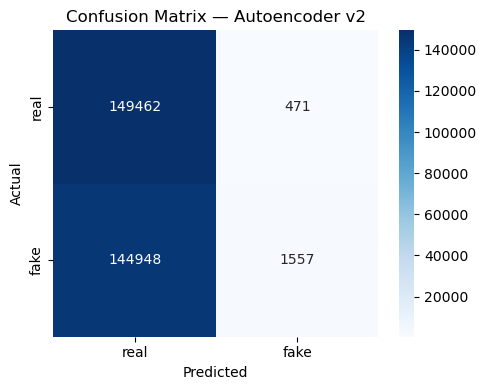

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test_arr, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["real", "fake"],
            yticklabels=["real", "fake"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Autoencoder v2")
plt.tight_layout()
plt.show()

## 9. Visualise Results

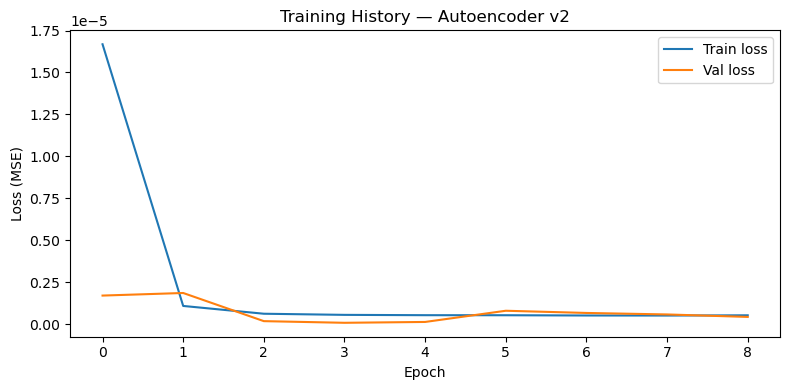

Saved: autoencoder_training_history.png


In [15]:
# Training history
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["loss"],     label="Train loss")
ax.plot(history.history["val_loss"], label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE)")
ax.set_title("Training History — Autoencoder v2")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "autoencoder_training_history.png", dpi=150)
plt.show()
print("Saved: autoencoder_training_history.png")

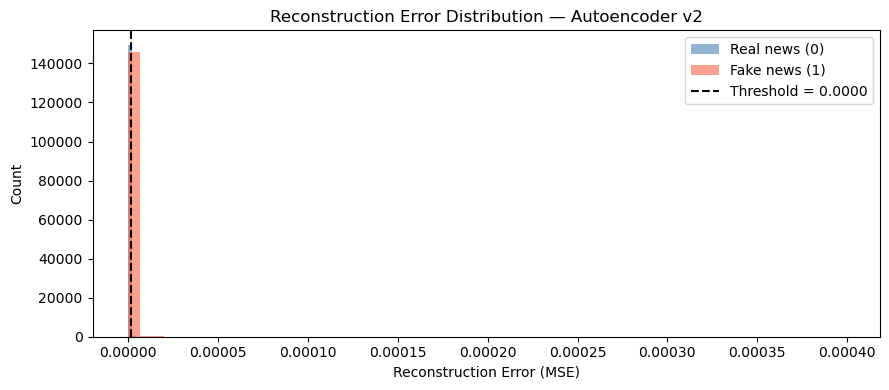

In [16]:
# Reconstruction error distribution by class
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(test_errors[y_test_arr == 0], bins=60, alpha=0.6,
        label="Real news (0)", color="steelblue")
ax.hist(test_errors[y_test_arr == 1], bins=60, alpha=0.6,
        label="Fake news (1)", color="tomato")
ax.axvline(threshold, color="black", linestyle="--", linewidth=1.5,
           label=f"Threshold = {threshold:.4f}")
ax.set_xlabel("Reconstruction Error (MSE)")
ax.set_ylabel("Count")
ax.set_title("Reconstruction Error Distribution — Autoencoder v2")
ax.legend()
plt.tight_layout()
plt.show()

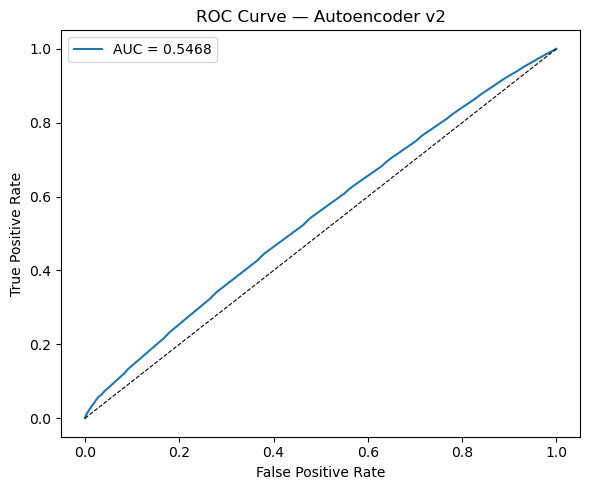

In [17]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test_arr, test_errors)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {roc:.4f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Autoencoder v2")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Save Models and Results

In [18]:
# Save trained model weights and config
weights_path = MODELS_DIR / "autoencoder.weights.h5"
autoencoder.save_weights(weights_path)
print("Saved model weights:", weights_path)

# Save model config for reconstruction
config_path = MODELS_DIR / "autoencoder_config.json"
with open(config_path, "w") as f:
    json.dump(autoencoder.get_config(), f, indent=2)
print("Saved model config :", config_path)

# Save tokenizer
tok_path = MODELS_DIR / "autoencoder_tokenizer.pkl"
with open(tok_path, "wb") as f:
    pickle.dump(tokenizer, f)
print("Saved tokenizer    :", tok_path)

# Save evaluation metrics (if available)
if 'results' in locals():
    res_path = MODELS_DIR / "autoencoder_results.json"
    with open(res_path, "w") as f:
        json.dump(results, f, indent=2)
    print("Saved results      :", res_path)

print("\nAll artifacts saved successfully.")
if 'results' in locals():
    print("\nFinal metrics summary:")

Saved model weights: c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers\results\models\autoencoder.weights.h5
Saved model config : c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers\results\models\autoencoder_config.json
Saved tokenizer    : c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers\results\models\autoencoder_tokenizer.pkl
Saved results      : c:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers\results\models\autoencoder_results.json

All artifacts saved successfully.

Final metrics summary:
